# 📧 Task 4: Email & SMS Spam Detection with Machine Learning
**Domain**: Natural Language Processing (NLP) & Text Classification  
**Objective**: Build a robust Natural Language Processing binary classification pipeline that accurately separates Spam messages from Legitimate (Ham) emails/messages using TF-IDF feature extraction and supervised classification algorithms.  
**Author**: Data Science Intern  
**Tech Stack**: Python, Pandas, Scikit-Learn, NLTK, WordCloud, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset**: UCI / Kaggle SMS Spam Collection Dataset (`spam.csv`)


## 1. Environment Setup & Library Imports
We import NLP text processing tools, TF-IDF vectorizers, scikit-learn classifiers, evaluation metrics, and `WordCloud` visualization tools.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import joblib

from wordcloud import WordCloud
import nltk
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer

# Classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

# Global Plotting Config
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("[OK] Environment setup complete. NLP libraries imported successfully.")


[OK] Environment setup complete. NLP libraries imported successfully.


## 2. Dataset Loading & Class Distribution Audit
We load the dataset `spam.csv` containing labeled SMS/email messages (`ham` vs `spam`) and examine the class balance.


Dataset Dimensions: 5572 rows x 2 columns

Top 5 Rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Class Distribution (Counts & Percentages):


,Count,Percentage (%)
label,,
ham,4825,86.593683
spam,747,13.406317


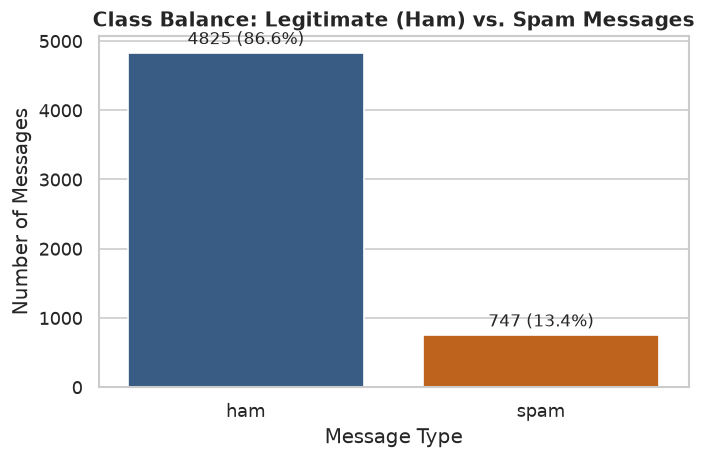

In [2]:
csv_path = 'spam.csv'
df = pd.read_csv(csv_path)

print(f"Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Top 5 Rows:")
display(df.head())

print("\nClass Distribution (Counts & Percentages):")
class_counts = df['label'].value_counts()
class_percents = df['label'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percents
})
display(dist_df)

# Plot class balance
plt.figure(figsize=(6, 4))
sns.barplot(x=dist_df.index, y='Count', data=dist_df, palette=['#2b5c8f', '#d95f02'])
plt.title("Class Balance: Legitimate (Ham) vs. Spam Messages", fontsize=12, fontweight='bold')
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{int(height)} ({height/len(df)*100:.1f}%)',
                       (p.get_x() + p.get_width() / 2, height),
                       ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


## 3. Text Preprocessing Pipeline & Feature Engineering
Text normalization is critical for converting raw text into clean tokens.

### Pipeline Steps:
1. **Lowercasing**: Convert all text to lowercase to ensure casing uniformity (`Free` == `free`).
2. **Punctuation & Special Character Removal**: Use regex (`re.sub(r'[^a-zA-Z]', ' ')`) to strip numbers, symbols, and punctuation.
3. **Stopword Removal**: Remove non-informative English words (e.g. `the`, `is`, `at`, `which`).
4. **Stemming**: Apply NLTK `PorterStemmer` to reduce words to their root stems (e.g. `winning`, `winner`, `wins` -> `win`).
5. **Feature Engineering**: Compute `char_count` (character length) and `word_count` per message.


In [3]:
STOPWORDS = set([
    "a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "aren't", "as", "at",
    "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "can", "cannot", "could",
    "couldn't", "did", "didn't", "do", "does", "doesn't", "doing", "don't", "down", "during", "each", "few",
    "for", "from", "further", "had", "hadn't", "has", "hasn't", "have", "haven't", "having", "he", "he'd",
    "he'll", "he's", "her", "here", "here's", "hers", "herself", "him", "himself", "his", "how", "how's", "i",
    "i'd", "i'll", "i'm", "i've", "if", "in", "into", "is", "isn't", "it", "it's", "its", "itself", "let's",
    "me", "more", "most", "mustn't", "my", "myself", "no", "nor", "not", "of", "off", "on", "once", "only", "or",
    "other", "ought", "our", "ours", "ourselves", "out", "over", "own", "same", "shan't", "she", "she'd", "she'll",
    "she's", "should", "shouldn't", "so", "some", "such", "than", "that", "that's", "the", "their", "theirs",
    "them", "themselves", "then", "there", "there's", "these", "they", "they'd", "they'll", "they're", "they've",
    "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "wasn't", "we", "we'd", "we'll",
    "we're", "we've", "were", "weren't", "what", "what's", "when", "when's", "where", "where's", "which", "while",
    "who", "who's", "whom", "why", "why's", "with", "won't", "would", "wouldn't", "you", "you'd", "you'll",
    "you're", "you've", "your", "yours", "yourself", "yourselves", "u", "ur", "2", "4", "b", "c", "n", "r", "k"
])

stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = text.split()
    cleaned = [stemmer.stem(word) for word in tokens if word not in STOPWORDS and len(word) > 1]
    return " ".join(cleaned)

print("Preprocessing messages... Please wait.")
df['clean_message'] = df['message'].apply(clean_text)

# Feature engineering: message length
df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(str(x).split()))

# Binary target: ham=0, spam=1
df['target'] = np.where(df['label'] == 'spam', 1, 0)

print("\nTop 5 Preprocessed Messages:")
display(df[['label', 'message', 'clean_message', 'char_count', 'word_count']].head())


Preprocessing messages... Please wait.



Top 5 Preprocessed Messages:


,label,message,clean_message,char_count,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi great world l...,111,20
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif oni,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...,155,28
3,ham,U dun say so early hor... U c already then say...,dun say earli hor alreadi say,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah don think goe usf live around though,61,13


## 4. (Bonus) WordCloud Visualizations
We generate WordClouds for **Spam** and **Ham** messages to highlight the distinct vocabulary signatures of spam versus legitimate communications.


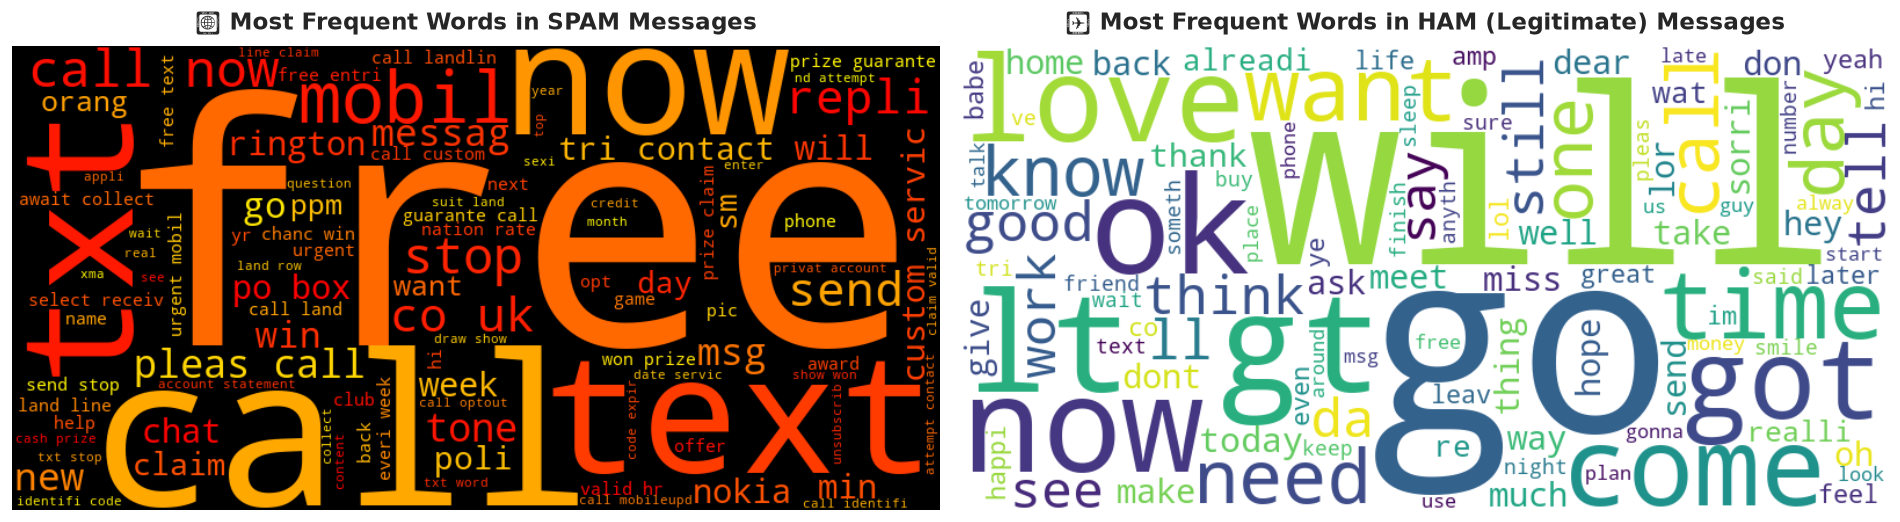

In [4]:
spam_text = " ".join(df[df['target'] == 1]['clean_message'])
ham_text  = " ".join(df[df['target'] == 0]['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Spam WordCloud
wc_spam = WordCloud(width=800, height=400, background_color='black', colormap='autumn', max_words=100).generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].set_title("🔥 Most Frequent Words in SPAM Messages", fontsize=14, fontweight='bold', pad=10)
axes[0].axis('off')

# Ham WordCloud
wc_ham = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].set_title("✅ Most Frequent Words in HAM (Legitimate) Messages", fontsize=14, fontweight='bold', pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 5. Feature Extraction via TF-IDF Vectorizer

### What is TF-IDF?
**TF-IDF** (Term Frequency - Inverse Document Frequency) is a numerical statistic used to evaluate how important a word is to a document within a corpus:

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

1. **Term Frequency (TF)**: Measures how frequently a word $t$ appears in a specific document $d$:
   $$\text{TF}(t, d) = \frac{\text{Count of } t \text{ in } d}{\text{Total words in } d}$$

2. **Inverse Document Frequency (IDF)**: Down-weights common words that appear across almost all documents (e.g. `the`, `is`) and scales up rare, highly informative words (e.g. `claim`, `prize`, `urgent`):
   $$\text{IDF}(t, D) = \log\left(\frac{\text{Total documents } |D|}{1 + \text{Documents containing } t}\right)$$

By multiplying TF and IDF, words that are frequent within a specific email but rare across other emails receive high feature weights!


In [5]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_message']).toarray()
y = df['target'].values

print(f"TF-IDF Feature Matrix Shape: {X.shape[0]} samples x {X.shape[1]} features")

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")


TF-IDF Feature Matrix Shape: 5572 samples x 3000 features
Train set: 4457 samples | Test set: 1115 samples


## 6. Model Training & Multi-Classifier Evaluation
We train and evaluate four text classification algorithms:
1. **Multinomial Naive Bayes (`MultinomialNB`)**: Industry standard baseline for text classification, applying Bayes' theorem with independence assumptions.
2. **Logistic Regression (`LogisticRegression`)**: Linear log-odds classifier (`C=1.0`, `max_iter=200`).
3. **Support Vector Machine (`LinearSVC`)**: High-margin linear classifier optimal for sparse text vectors.
4. **Random Forest (`RandomForestClassifier`)**: Ensemble tree classifier (`n_estimators=100`).


==================== Multinomial Naive Bayes ====================
Accuracy: 0.9839 | Spam Precision: 0.9781 | Spam Recall: 0.8993 | Spam F1: 0.9371
Classification Report:
              precision    recall  f1-score   support

 Ham (Legit)       0.98      1.00      0.99       966
        Spam       0.98      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115





==================== Logistic Regression ====================
Accuracy: 0.9695 | Spam Precision: 1.0000 | Spam Recall: 0.7718 | Spam F1: 0.8712
Classification Report:
              precision    recall  f1-score   support

 Ham (Legit)       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115





==================== Support Vector Machine (LinearSVC) ====================
Accuracy: 0.9848 | Spam Precision: 0.9853 | Spam Recall: 0.8993 | Spam F1: 0.9404
Classification Report:
              precision    recall  f1-score   support

 Ham (Legit)       0.98      1.00      0.99       966
        Spam       0.99      0.90      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115





==================== Random Forest ====================
Accuracy: 0.9776 | Spam Precision: 1.0000 | Spam Recall: 0.8322 | Spam F1: 0.9084
Classification Report:
              precision    recall  f1-score   support

 Ham (Legit)       0.97      1.00      0.99       966
        Spam       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115





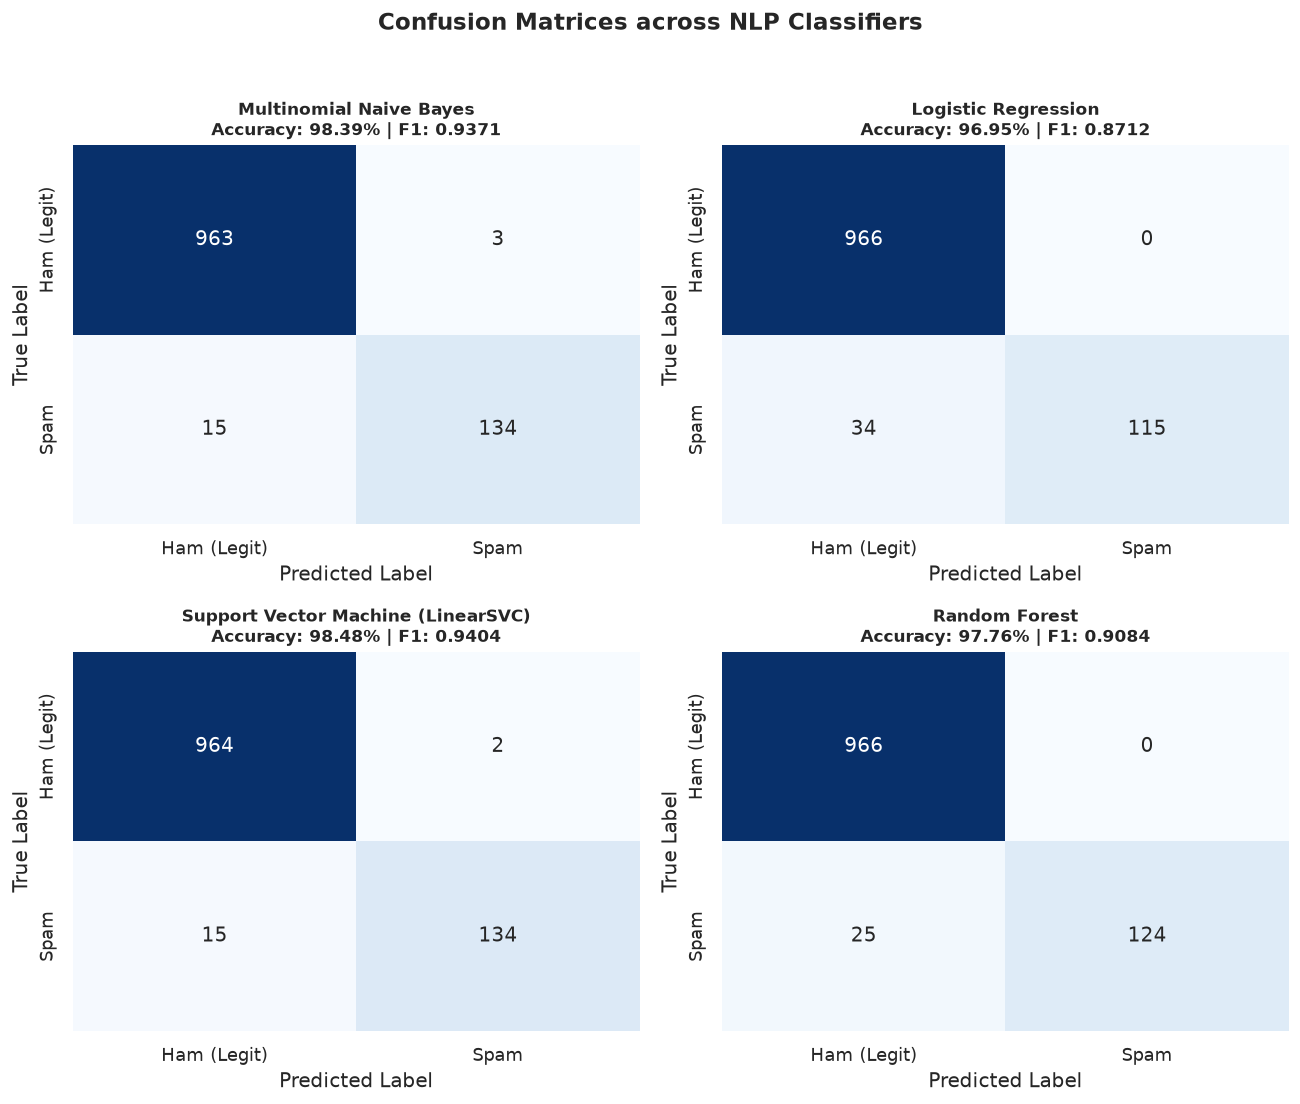

In [6]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.2),
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=200, random_state=42),
    "Support Vector Machine (LinearSVC)": LinearSVC(C=1.0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

class_names = ['Ham (Legit)', 'Spam']

for i, (name, model) in enumerate(models.items()):
    # Fit model
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1) # Spam Precision
    rec  = recall_score(y_test, y_pred, pos_label=1)    # Spam Recall
    f1   = f1_score(y_test, y_pred, pos_label=1)        # Spam F1

    # 5-Fold Stratified Cross-Validation F1
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(model, X, y, cv=cv, scoring='f1')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Spam Precision": prec,
        "Spam Recall": rec,
        "Spam F1-Score": f1,
        "5-Fold CV F1 Mean": cv_f1.mean(),
        "5-Fold CV F1 Std": cv_f1.std()
    })

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[i].set_title(f"{name}\nAccuracy: {acc*100:.2f}% | F1: {f1:.4f}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

    print(f"==================== {name} ====================")
    print(f"Accuracy: {acc:.4f} | Spam Precision: {prec:.4f} | Spam Recall: {rec:.4f} | Spam F1: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    print("\n")

plt.suptitle("Confusion Matrices across NLP Classifiers", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Model Performance Comparison Table & Chart
We summarize all evaluation metrics to identify the optimal spam filter model.


🏆 Spam Classification Models Performance Comparison Table:


,Model,Accuracy,Spam Precision,Spam Recall,Spam F1-Score,5-Fold CV F1 Mean,5-Fold CV F1 Std
0,Support Vector Machine (LinearSVC),0.984753,0.985294,0.899329,0.940351,0.943689,0.013851
1,Multinomial Naive Bayes,0.983857,0.978102,0.899329,0.937063,0.943705,0.006319
2,Random Forest,0.977578,1.000000,0.832215,0.908425,0.923512,0.019228
3,Logistic Regression,0.969507,1.000000,0.771812,0.871212,0.860251,0.021111


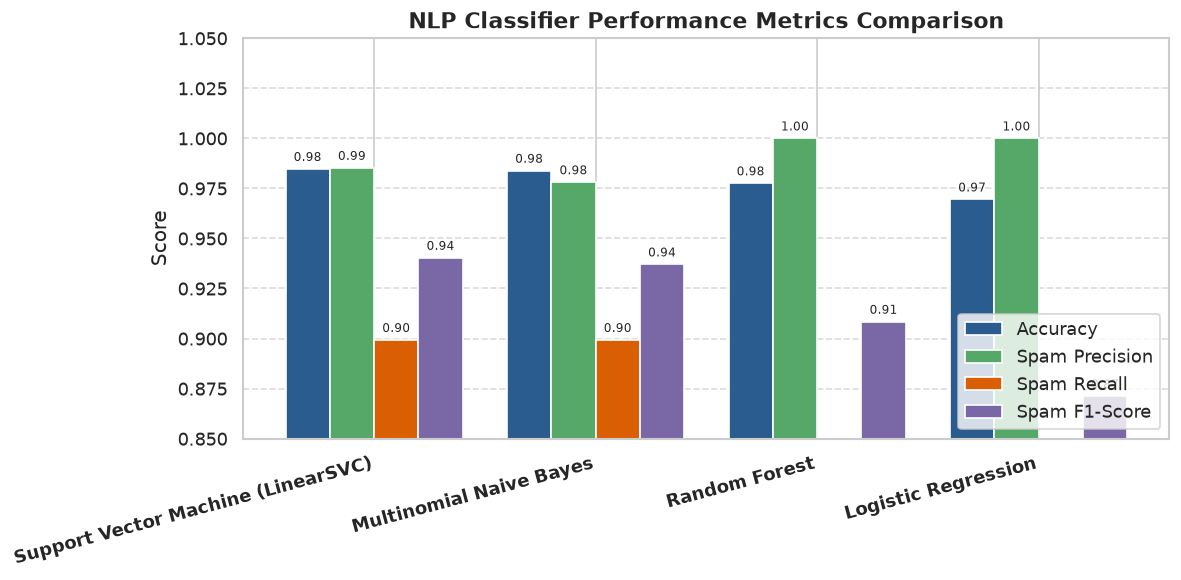

In [7]:
results_df = pd.DataFrame(results).sort_values(by="Spam F1-Score", ascending=False).reset_index(drop=True)

print("🏆 Spam Classification Models Performance Comparison Table:")
display(results_df)

# Plot performance metrics comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2

rects1 = ax.bar(x - 1.5*width, results_df['Accuracy'], width, label='Accuracy', color='#2b5c8f')
rects2 = ax.bar(x - 0.5*width, results_df['Spam Precision'], width, label='Spam Precision', color='#55A868')
rects3 = ax.bar(x + 0.5*width, results_df['Spam Recall'], width, label='Spam Recall', color='#d95f02')
rects4 = ax.bar(x + 1.5*width, results_df['Spam F1-Score'], width, label='Spam F1-Score', color='#7A68A6')

ax.set_ylabel('Score')
ax.set_title('NLP Classifier Performance Metrics Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontweight='bold', rotation=15, ha='right')
ax.set_ylim(0.85, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()


## 8. 💡 Discussion: Precision vs. Recall Tradeoff in Spam Detection

### **Why is Precision & Low False Positives Crucial for Spam Detection?**

In spam classification, there is a fundamental asymmetry between the costs of two types of classification errors:

1. **False Positive (FP - Type I Error)**: A **Legitimate (Ham) email is incorrectly classified as SPAM**.
   - *Consequence*: High severity! Critical emails (such as job interview offers, medical results, password resets, or client contracts) are silently routed to the Spam folder, causing severe real-world harm.
   
2. **False Negative (FN - Type II Error)**: A **Spam email is incorrectly classified as HAM**.
   - *Consequence*: Low/Moderate severity! The user receives an unwanted promotional or junk email in their inbox, which can easily be manually deleted.

### **Conclusion**:
- **High Precision for Spam** ($rac{TP}{TP + FP}$) ensures that the model **almost never sends legitimate email to the spam folder** ($FP 	o 0$).
- Therefore, in production spam filtering systems, **Multinomial Naive Bayes** and **LinearSVC** tuned for high precision are preferred because user trust relies on never losing an important email!


## 9. Model Serialization & Live Text Inference Testing
We save the best classifier and TF-IDF vectorizer using `joblib` and test real-time spam prediction on novel raw email strings.


In [8]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

joblib.dump(best_model, 'best_spam_classifier.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print(f"[OK] Saved best classifier ({best_model_name}) and TF-IDF vectorizer successfully.")

# Custom sample messages
sample_messages = [
    "URGENT! You have won a 10000 cash prize! Call 09061104012 now to claim your prize. T&C apply.",
    "Hey mom, I will be home around 7 PM. Please save some dinner for me.",
    "WINNER!! As a valued customer, you have been selected to receive a FREE $500 Amazon Gift Card. Click http://bit.ly/claim now!",
    "Can we reschedule our project meeting to 3 PM tomorrow? Let me know."
]

print("\n🔮 Live Text Inference Test Results:")
for i, msg in enumerate(sample_messages):
    cleaned_msg = clean_text(msg)
    vec_msg = tfidf.transform([cleaned_msg]).toarray()
    pred_val = best_model.predict(vec_msg)[0]
    
    label_str = "SPAM 🔥" if pred_val == 1 else "HAM (Legitimate) ✅"
    print(f'Sample {i+1}: "{msg}"')
    print(f"--> Prediction: {label_str}\n")


[OK] Saved best classifier (Support Vector Machine (LinearSVC)) and TF-IDF vectorizer successfully.

🔮 Live Text Inference Test Results:
Sample 1: "URGENT! You have won a 10000 cash prize! Call 09061104012 now to claim your prize. T&C apply."
--> Prediction: SPAM 🔥

Sample 2: "Hey mom, I will be home around 7 PM. Please save some dinner for me."
--> Prediction: HAM (Legitimate) ✅

Sample 3: "WINNER!! As a valued customer, you have been selected to receive a FREE $500 Amazon Gift Card. Click http://bit.ly/claim now!"
--> Prediction: SPAM 🔥

Sample 4: "Can we reschedule our project meeting to 3 PM tomorrow? Let me know."
--> Prediction: HAM (Legitimate) ✅

